# Tarea 1 — Mapa de Tiros del Equipo Local

> Usando el scraping de StatsBomb (tema 2), obtener el `event_id` de un partido y mostrar el mapa de tiros del equipo local.

**Partido seleccionado:** Atlético de Madrid 1-0 Barcelona — La Liga 2020/2021 (21 de noviembre de 2020)

**event_id / match_id:** `3773656`

In [1]:
# Instalacion de dependencias necesarias
%pip install statsbomb mplsoccer

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importacion de librerias
# numpy: operaciones numericas para manejo de coordenadas
# pandas: manipulacion de datos tabulares para filtrar eventos de tiro
# statsbomb: libreria alternativa de StatsBomb con interfaz orientada a objetos
# mplsoccer.VerticalPitch: dibuja la cancha en orientacion vertical (ideal para mapas de tiro)
# matplotlib.pyplot: libreria base para gestion de figuras y visualizacion
import numpy as np
import pandas as pd
import statsbomb as sb
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch

In [3]:
# Carga de eventos del partido Atletico de Madrid vs Barcelona (La Liga 2020/21)
# event_id='3773656' corresponde al partido del 21 de noviembre de 2020
# Atletico de Madrid (local) gano 1-0 a Barcelona
events = sb.Events(event_id='3773656')

# Extraemos solo los eventos de tipo 'shot' (tiro)
# El DataFrame resultante contiene columnas especificas de tiros:
#   statsbomb_xg: probabilidad de gol esperado (0-1)
#   start_location_x/y: origen del tiro en coordenadas StatsBomb (120x80)
#   outcome: resultado del tiro (Goal, Saved, Blocked, Off T, etc.)
df = events.get_dataframe(event_type='shot')
df.head()

/opt/anaconda3/lib/python3.13/site-packages/statsbomb/parser.py:86: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[name_cols] = df[name_cols].applymap(get_event_name)


,event_type,id,index,period,timestamp,minute,second,possession,possession_team,play_pattern,...,follows_dribble,redirect,one_on_one,open_goal,deflected,start_location_x,start_location_y,end_location_x,end_location_y,end_location_z
0,shot,e3dcd73c-9f2e-4995-98c5-e6ec478e9e28,146,1,00:02:10.291,2,10,3,Barcelona,From Throw In,...,None,None,None,None,None,114.2,47.5,120.0,39.8,4.0
1,shot,101fb1d5-7731-454e-b756-29c5732fabe8,287,1,00:04:32.527,4,32,6,Atlético Madrid,Regular Play,...,None,None,None,None,None,98.8,30.7,118.2,36.4,2.3
2,shot,3f5a3a05-0ba4-4880-817f-5861425cb049,539,1,00:11:00.898,11,0,15,Atlético Madrid,From Corner,...,None,None,None,None,None,110.2,52.9,120.0,42.0,2.8
3,shot,f5aa826c-8e77-4d3d-a812-b6f36ca32f82,1525,1,00:34:10.411,34,10,56,Atlético Madrid,From Free Kick,...,None,None,None,None,None,94.9,26.2,120.0,53.1,0.9
4,shot,5f24ae84-aba9-4aef-8dfd-58bbca2e5e92,1874,1,00:40:30.575,40,30,64,Barcelona,From Free Kick,...,None,None,None,None,None,116.2,31.2,118.4,36.4,0.2


In [4]:
# Filtramos los tiros del equipo local: Atletico de Madrid
# .copy() crea una copia independiente para evitar SettingWithCopyWarning
atletico_color = "#CE3524"  # Color rojo del Atletico de Madrid
atletico_df = df[df["team"] == "Atlético Madrid"].copy()

# Verificamos cuantos tiros realizo el Atletico en el partido
print(f"Tiros totales del Atletico de Madrid: {len(atletico_df)}")
print(f"Goles: {len(atletico_df[atletico_df['outcome'] == 'Goal'])}")
print(f"\nDetalle de tiros:")
print(atletico_df[['player', 'outcome', 'statsbomb_xg', 'start_location_x', 'start_location_y']])

Tiros totales del Atletico de Madrid: 10
Goles: 1

Detalle de tiros:
                       player  outcome  statsbomb_xg  start_location_x  \
1        Saúl Ñíguez Esclapez    Saved      0.039626              98.8   
2      Marcos Llorente Moreno     Post      0.122611             110.2   
3        Saúl Ñíguez Esclapez    Off T      0.024587              94.9   
5   Yannick Ferreira Carrasco     Goal      0.107528              88.7   
9        Saúl Ñíguez Esclapez  Blocked      0.044968             105.7   
12        João Félix Sequeira  Blocked      0.037846              94.3   
13       Saúl Ñíguez Esclapez  Wayward      0.049725             114.1   
14  Yannick Ferreira Carrasco    Off T      0.014156             109.5   
18        Ángel Martín Correa  Blocked      0.032241              92.6   
19  Yannick Ferreira Carrasco    Off T      0.089642             103.0   

    start_location_y  
1               30.7  
2               52.9  
3               26.2  
5               20.6  
9

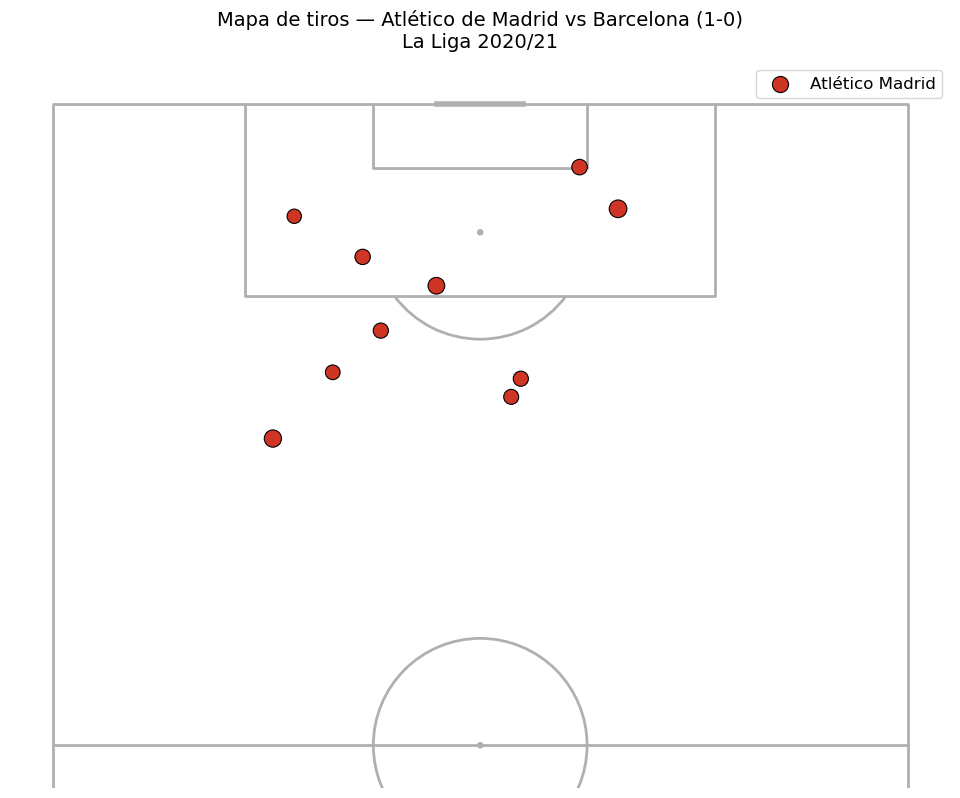

In [5]:
# Visualizacion del mapa de tiros del Atletico de Madrid (equipo local)
# VerticalPitch con half=True muestra solo la mitad de ataque de la cancha,
# que es el formato estandar para mapas de tiro — maximiza el espacio visual
# en el ultimo tercio y elimina la mitad defensiva que no aporta informacion.
pitch = VerticalPitch(half=True)
fig, ax = pitch.draw(figsize=(10, 8))

# Dibujamos los tiros con tamano proporcional al xG (gol esperado)
# s = statsbomb_xg * 500 + 100:
#   +100 base asegura que todos los tiros sean visibles sin importar su xG
#   *500 amplifica las diferencias — un tiro de 0.5 xG tiene s=350
# c= asigna color uniforme rojo del Atletico
# label= registra entrada de leyenda para esta serie
atletico_sc = pitch.scatter(
    x=atletico_df["start_location_x"],
    y=atletico_df["start_location_y"],
    ax=ax,
    c=atletico_color,
    label="Atlético Madrid",
    s=atletico_df["statsbomb_xg"] * 500 + 100,
    edgecolors='black',
    linewidth=0.8
)
ax.legend(fontsize=12)
ax.set_title("Mapa de tiros — Atlético de Madrid vs Barcelona (1-0)\nLa Liga 2020/21", fontsize=14, pad=10)

plt.show()

## Analisis del mapa de tiros

El Atletico de Madrid realizo **10 tiros** en este partido frente a 13 del Barcelona, lo que muestra un equilibrio relativo en los intentos a puerta. Sin embargo, el Atletico fue mas eficiente convirtiendo 1 gol de sus oportunidades.

La distribucion de tiros del Atletico muestra un patron clasico del equipo de Simeone:

1. **Tiros dispersos desde fuera del area:** Varios intentos de **Saul Niguez** se originaron desde posiciones alejadas de la porteria, con valores de xG bajos, lo que indica disparos de larga distancia con poca probabilidad de gol.

2. **Transiciones rapidas:** El gol de **Yannick Carrasco** se produjo desde una posicion relativamente lejana (x=88.7), lo que sugiere un contragolpe aprovechado con velocidad — un recurso tipico del Atletico del Cholo.

3. **Marcos Llorente como amenaza:** Su tiro al poste (xG=0.12) desde una posicion favorable muestra como Llorente, reconvertido de centrocampista a jugador de banda, llegaba al area rival con peligro.

4. **Bloqueo defensivo del Barcelona:** Varios tiros del Atletico fueron bloqueados (Blocked), lo que indica que pese a llegar a posiciones de disparo, la defensa del Barcelona se interpuso fisicamente.

**Conclusion:** El Atletico de Madrid mostro su ADN tactico: bloque bajo defensivo, pocos pero efectivos contragolpes, y aprovechamiento de las pocas oportunidades claras. El unico gol de Carrasco desde una posicion atipica refleja la capacidad del equipo de Simeone para ser letal sin necesidad de dominar la posesion.